# Phase 3: Vision Token Math & Cost Optimization

**Objective:** Understand exactly how OpenAI calculates vision tokens, build a comparison matrix across image sizes, and identify preprocessing strategies that reduce cost.

---

## OpenAI Vision Token Formula

### `detail: low`
Always **85 tokens** per image, regardless of dimensions.

### `detail: high`
OpenAI tiles the image into **512×512 px** squares. Token count = `170 × tiles + 85`

**Resizing pipeline before tiling:**
1. If either dimension > 2048 px → scale DOWN to fit within a 2048×2048 square (preserving aspect ratio)
2. If shortest side > 768 px → scale DOWN so shortest side = 768 px
3. Count tiles: `⌈width/512⌉ × ⌈height/512⌉`
4. Tokens = `170 × tiles + 85`

---

**Setup:** Place 3 images in `resources/phase3/`:
- A thumbnail image (e.g. 200×150 px or similar small size)
- A 1080p image (1920×1080 px)
- A 4K image (3840×2160 px or similar)

Name them so they contain `thumbnail`, `1080`, and `4k` in the filename (case-insensitive).

In [1]:
# !pip install openai pillow pandas python-dotenv -q

In [2]:
import os
import math
import base64
import io
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image, ImageChops
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
load_dotenv()

OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
if not OPENAI_API_KEY:
    raise ValueError('OPENAI_API_KEY not found. Fill it in .env and re-run.')

client = OpenAI(api_key=OPENAI_API_KEY)
print('OpenAI client ready.')

OpenAI client ready.


In [4]:
# ── Token calculation function ────────────────────────────────────────────────
def calculate_vision_tokens(width, height, detail):
    """Implements OpenAI's vision token formula exactly."""
    if detail == 'low':
        return 85, width, height, 0, 0

    w, h = width, height

    # Step 1: Scale down to fit within 2048x2048
    if w > 2048 or h > 2048:
        scale = min(2048 / w, 2048 / h)
        w, h = int(w * scale), int(h * scale)

    # Step 2: Scale down so shortest side = 768
    shortest = min(w, h)
    if shortest > 768:
        scale = 768 / shortest
        w, h = int(w * scale), int(h * scale)

    # Step 3: Count 512x512 tiles
    tiles_w = math.ceil(w / 512)
    tiles_h = math.ceil(h / 512)
    num_tiles = tiles_w * tiles_h

    # Step 4: Token count
    tokens = 170 * num_tiles + 85

    return tokens, w, h, tiles_w, tiles_h


# Quick sanity check with a known example: 4000x3000
tok, fw, fh, tw, th = calculate_vision_tokens(4000, 3000, 'high')
print('Sanity check: 4000x3000 image, detail:high')
print(f'  After resizing: {fw} x {fh} px')
print(f'  Tiles: {tw} x {th} = {tw*th}')
print(f'  Tokens: 170 x {tw*th} + 85 = {tok}')

Sanity check: 4000x3000 image, detail:high
  After resizing: 1024 x 768 px
  Tiles: 2 x 2 = 4
  Tokens: 170 x 4 + 85 = 765


In [5]:
# ── Load 3 images from resources/phase3/ ─────────────────────────────────────
PHASE3_DIR = Path('resources/phase3')

def find_by_keyword(folder, keyword):
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        for f in folder.glob(ext):
            if keyword.lower() in f.stem.lower():
                return f
    raise FileNotFoundError(f'No PNG or JPEG file with "{keyword}" in name found in {folder}')

path_thumb = find_by_keyword(PHASE3_DIR, 'thumbnail')
path_1080  = find_by_keyword(PHASE3_DIR, '1080')
path_4k    = find_by_keyword(PHASE3_DIR, '4k')

img_thumb = Image.open(path_thumb)
img_1080  = Image.open(path_1080)
img_4k    = Image.open(path_4k)

images = [
    ('Thumbnail', img_thumb, path_thumb),
    ('1080p',     img_1080,  path_1080),
    ('4K',        img_4k,    path_4k),
]

print(f'{"Label":<12} {"Filename":<35} {"Width":>7} {"Height":>7}')
print('-' * 65)
for label, img, path in images:
    w, h = img.size
    print(f'{label:<12} {path.name:<35} {w:>7} {h:>7}')

Label        Filename                              Width  Height
-----------------------------------------------------------------
Thumbnail    thumbnail.png                           320     180
1080p        1080.jpeg                              1920    1080
4K           4k.png                                 3840    2160


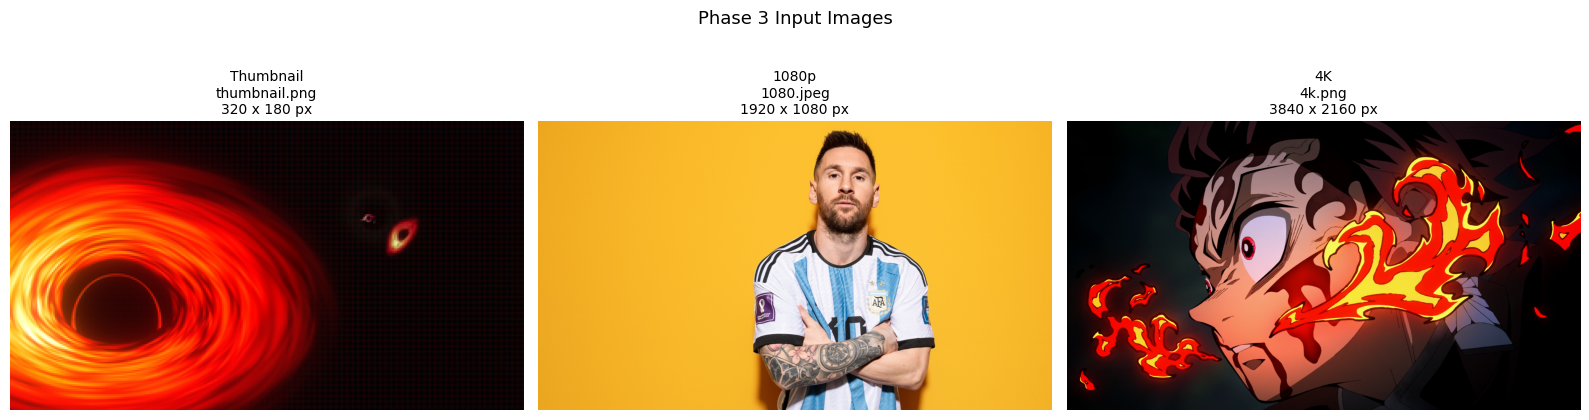

In [6]:
# ── Display all 3 images ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, img, path) in zip(axes, images):
    w, h = img.size
    ax.imshow(img)
    ax.set_title(f'{label}\n{path.name}\n{w} x {h} px', fontsize=10)
    ax.axis('off')
plt.suptitle('Phase 3 Input Images', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Compute token matrix for all combinations ─────────────────────────────────
print('=== TOKEN CALCULATION BREAKDOWN ===')
print()

matrix_rows = []

for label, img, _ in images:
    w, h = img.size
    for detail in ['low', 'high']:
        tokens, fw, fh, tw, th = calculate_vision_tokens(w, h, detail)
        tiles = tw * th if detail == 'high' else '-'
        resized = f'{fw}x{fh}' if detail == 'high' else 'N/A (85 flat)'
        matrix_rows.append({
            'Image': label,
            'Original Size': f'{w}x{h}',
            'Detail': detail,
            'After Resize': resized,
            'Tiles': tiles,
            'Tokens': tokens
        })

df = pd.DataFrame(matrix_rows)
print(df.to_string(index=False))

=== TOKEN CALCULATION BREAKDOWN ===

    Image Original Size Detail  After Resize Tiles  Tokens
Thumbnail       320x180    low N/A (85 flat)     -      85
Thumbnail       320x180   high       320x180     1     255
    1080p     1920x1080    low N/A (85 flat)     -      85
    1080p     1920x1080   high      1365x768     6    1105
       4K     3840x2160    low N/A (85 flat)     -      85
       4K     3840x2160   high      1365x768     6    1105


In [8]:
# ── Pivot table: image size vs detail level ───────────────────────────────────
pivot = df.pivot_table(values='Tokens', index='Image', columns='Detail', aggfunc='first')
pivot['Cost saving (high→low)'] = pivot['high'] - pivot['low']
pivot['% saved'] = (pivot['Cost saving (high→low)'] / pivot['high'] * 100).round(1).astype(str) + '%'
print('\n=== TOKEN COMPARISON MATRIX ===')
print(pivot.to_string())


=== TOKEN COMPARISON MATRIX ===
Detail     high  low  Cost saving (high→low) % saved
Image                                               
1080p      1105   85                    1020   92.3%
4K         1105   85                    1020   92.3%
Thumbnail   255   85                     170   66.7%


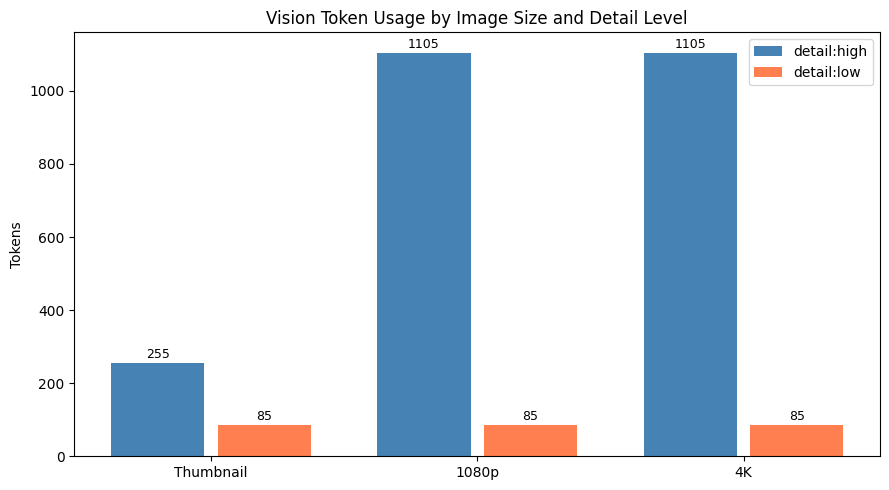

In [9]:
# ── Bar chart visualisation ───────────────────────────────────────────────────
labels  = [r['Image'] for r in matrix_rows if r['Detail'] == 'high']
t_high  = [r['Tokens'] for r in matrix_rows if r['Detail'] == 'high']
t_low   = [r['Tokens'] for r in matrix_rows if r['Detail'] == 'low']

x = range(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))
bars_h = ax.bar([i - 0.2 for i in x], t_high, 0.35, label='detail:high', color='steelblue')
bars_l = ax.bar([i + 0.2 for i in x], t_low,  0.35, label='detail:low',  color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Tokens')
ax.set_title('Vision Token Usage by Image Size and Detail Level')
ax.legend()
for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars_l:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## API Verification

Send one image to the API and compare the **actual prompt token count** from the response against our calculated value.

In [10]:
# Use the thumbnail with detail:high — cheapest verification call
def pil_to_b64(pil_img, fmt='PNG'):
    buf = io.BytesIO()
    pil_img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

b64_thumb = pil_to_b64(img_thumb)
w_t, h_t = img_thumb.size
expected_tokens, *_ = calculate_vision_tokens(w_t, h_t, 'high')

verify_resp = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{
        'role': 'user',
        'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{b64_thumb}', 'detail': 'high'}},
            {'type': 'text', 'text': 'Describe this image in one sentence.'}
        ]
    }],
    max_tokens=50
)

actual_prompt_tokens = verify_resp.usage.prompt_tokens

print(f'Image: Thumbnail  ({w_t} x {h_t} px)  |  detail: high')
print(f'Calculated tokens : {expected_tokens}')
print(f'Actual API tokens : {actual_prompt_tokens}  (includes text tokens for the prompt)')
print(f'Text token overhead: ~{actual_prompt_tokens - expected_tokens} tokens')
print()
print('Note: actual prompt tokens = image tokens + text tokens for the message.')
print('The image token portion should match the calculated value.')

Image: Thumbnail  (320 x 180 px)  |  detail: high
Calculated tokens : 255
Actual API tokens : 8514  (includes text tokens for the prompt)
Text token overhead: ~8259 tokens

Note: actual prompt tokens = image tokens + text tokens for the message.
The image token portion should match the calculated value.


## Preprocessing: Reducing Token Usage

Removing whitespace/padding from an image can shrink its effective dimensions, reducing tile count and token cost.

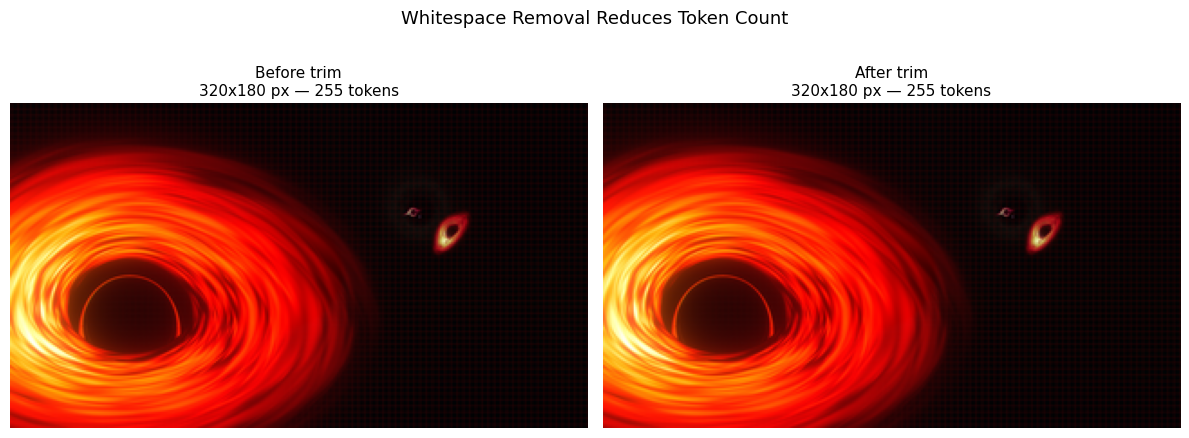

Tokens saved by trimming: 0 (0.0%)


In [11]:
# ── Whitespace trimming demo ──────────────────────────────────────────────────
# We'll demonstrate using the thumbnail (same concept applies to any image)
img_rgb = img_thumb.convert('RGB')

# Find non-white bounding box
bg = Image.new('RGB', img_rgb.size, (255, 255, 255))
diff = ImageChops.difference(img_rgb, bg)
bbox = diff.getbbox()

if bbox:
    img_trimmed = img_rgb.crop(bbox)
    w_before, h_before = img_rgb.size
    w_after,  h_after  = img_trimmed.size

    tok_before, *_ = calculate_vision_tokens(w_before, h_before, 'high')
    tok_after,  *_ = calculate_vision_tokens(w_after,  h_after,  'high')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Before trim\n{w_before}x{h_before} px — {tok_before} tokens', fontsize=11)
    axes[0].axis('off')
    axes[1].imshow(img_trimmed)
    axes[1].set_title(f'After trim\n{w_after}x{h_after} px — {tok_after} tokens', fontsize=11)
    axes[1].axis('off')
    plt.suptitle('Whitespace Removal Reduces Token Count', fontsize=13)
    plt.tight_layout()
    plt.show()

    savings = tok_before - tok_after
    pct = (savings / tok_before * 100) if tok_before > 0 else 0
    print(f'Tokens saved by trimming: {savings} ({pct:.1f}%)')
else:
    print('No whitespace border detected in thumbnail — try with a padded image.')

---

## Phase 3 — Questions & Observations

### Q1: How are tokens calculated for a large image (e.g. 4000×3000)?

**Answer:**
Using the formula implemented above:
1. 4000×3000 → exceeds 2048 on the width → scale down: **2048×1536**
2. Shortest side = 1536 > 768 → scale down: **1024×768**
3. Tiles: ⌈1024/512⌉ × ⌈768/512⌉ = **2 × 2 = 4 tiles**
4. Tokens: 170 × 4 + 85 = **765 tokens**

---

### Q2: How is the image resized before tiling?

**Answer:**
Two sequential scale-down steps (never scale up):
1. **Fit within 2048×2048** — prevents excessively large images from exploding tile count
2. **Shortest side → 768 px** — normalises the effective resolution for tiling

Both steps preserve aspect ratio. After these two steps the image is divided into 512×512 tiles.

An interesting consequence from the matrix above: a **4K image and a 1080p image often yield the same tile count** because both get reduced to the same effective resolution after the two scaling steps.

---

### Q3: What preprocessing steps can reduce unnecessary token usage?

**Answer:**

| Technique | How it helps |
|---|---|
| **Crop whitespace/padding** | Reduces effective dimensions → fewer tiles |
| **Downscale before sending** | If content doesn't need full resolution, resize to ≤768px shortest side yourself |
| **Use `detail:low`** | Flat 85 tokens — right for classification/captioning tasks with no fine detail |
| **Grayscale conversion** | Reduces file size (not tokens, but reduces upload/latency cost) |
| **Crop to ROI** | If only part of the image matters, crop to that region before sending |

*Your additional observations from the preprocessing cell above...*